<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/KMeans_Clustering_and_Heirarchical_Clustering_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset: Mall_Customer Dataset**

The **Mall Customer Segmentation** dataset is one of the most popular datasets used by beginners and professionals alike to practice **Unsupervised Machine Learning**, specifically K-Means clustering. It is a synthetic dataset created to simulate the real-world problem of "Customer Personality Analysis."

The core goal of using this dataset is to divide a mall's customer base into distinct groups (segments) based on their behavior and demographics, allowing a marketing team to target each group with specific strategies.

### 1. Dataset Structure
The dataset is typically a simple CSV file with **200 rows** (customers) and **5 columns** (features):

* **CustomerID:** A unique ID for each customer (usually dropped during analysis as it has no predictive power).
* **Gender:** Male or Female.
* **Age:** The age of the customer (ranging from 18 to 70).
* **Annual Income (k$):** The yearly income of the customer in thousands of dollars.
* **Spending Score (1-100):** A score assigned by the mall based on customer behavior and purchasing patterns. 1 is a low spender; 100 is a high spender.

### 2. The Key Relationship
When learning K-Means with this dataset, the most important relationship to visualize is **Annual Income vs. Spending Score**. When you plot these two features on a scatter plot, five very distinct natural clusters usually emerge.



### 3. Interpreting the 5 Common Clusters
After running a K-Means algorithm (usually with $k=5$), you can categorize the customers into these personas:

1.  **The "Sensible" (Middle Class):** Average income and average spending. These are the "steady" customers.
2.  **The "Careless" (Target Group):** Low income but high spending score. These customers might be younger or impulsive buyers.
3.  **The "Stingy":** High income but very low spending score. These are people with money who choose not to spend it at this mall.
4.  **The "Target/Stars":** High income and high spending score. These are the mall's most valuable customers.
5.  **The "Careful":** Low income and low spending score.

### 4. Why it is great for learning Clustering
* **Intuitive Results:** Unlike abstract data, the "Target" or "Careless" groups make immediate business sense.
* **The Elbow Method works perfectly:** If you calculate the **Within-Cluster Sum of Squares (WCSS)** for different $k$ values, the "elbow" at $k=5$ is incredibly clear, making it a perfect textbook example.



* **Multidimensional Practice:** While 2D plots are easy, you can also include **Age** to create 3D clusters, teaching you how K-Means handles more than two features.

### 5. Practical Use Case
If you were the Mall Manager, you would use these clusters to make decisions:
* **For "Stingy" customers:** Send them high-value discount coupons for luxury items to entice them to spend their high income.
* **For "Stars":** Invite them to exclusive "Platinum Member" events or early-access sales to maintain their loyalty.
* **For "Careless":** Send them alerts about trendy, fast-fashion sales.

# **Import Necessary Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import scipy.cluster.hierarchy as sch

# Scikit-Learn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score, davies_bouldin_score)

# Plot Settings
plt.rcParams.update({
    'figure.facecolor': '#0F1E2E',
    'axes.facecolor':   '#162637',
    'axes.edgecolor':   '#2A3A4A',
    'axes.labelcolor':  '#C8D8E8',
    'xtick.color':      '#8BA8BE',
    'ytick.color':      '#8BA8BE',
    'text.color':       '#C8D8E8',
    'grid.color':       '#2A3A4A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#162637',
    'legend.edgecolor': '#2A3A4A',
    'figure.titlesize': 16,
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'font.family':      'monospace',
})

PALETTE = ['#00C6A7', '#F7941D', '#4EC9E5', '#FF6B6B',
           '#A78BFA', '#34D399', '#FB923C', '#38BDF8']

np.random.seed(42)

#load dataset
df=pd.read_csv('https://raw.githubusercontent.com/themehmi/datasets/refs/heads/main/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Data Preprocessing**

In [ ]:
#encoding
df['Gender']=df['Gender'].map({'Male':0,'Female':1})
df.head()
#Drop Irrelevant Columns
df.drop('CustomerID', axis=1, inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


**Feature Selection**

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
#Feature Scaling
scaler=StandardScaler()
X_scaled = StandardScaler
X_scaled = scaler.fit_transform(X)



---



---



# **Cluster Evaluation Metrics**

Since clustering is unsupervised, we cannot use accuracy. Instead, we use **internal validation metrics** — no ground truth needed!

**The Three Main Metrics**

### 1. Silhouette Score
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
- $a(i)$ = intra-cluster distance (cohesion)
- $b(i)$ = nearest-cluster distance (separation)
- **Range:** −1 to +1 | **Higher is better**

### 2. Calinski-Harabász (CH) Index
$$CH = \frac{\text{Between-cluster dispersion} / (K-1)}{\text{Within-cluster dispersion} / (n-K)}$$
- **Range:** 0 to ∞ | **Higher is better**

### 3. Davies-Bouldin Index
$$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \frac{\sigma_i + \sigma_j}{d(c_i, c_j)}$$
- $\sigma_k$ = average distance from cluster $k$ to its centroid
- $d(c_i, c_j)$ = distance between centroids $i$ and $j$
- **Range:** 0 to ∞ | **Lower is better**


# **Practical 1**

# **K-Means Clustering**
At its core, **K-Means Clustering** is an unsupervised machine learning algorithm used to group data points into "clusters" based on their similarities. Because it is "unsupervised," the algorithm doesn't have pre-existing labels; it looks for patterns and structures on its own.

The "**K**" represents the number of groups (clusters) you want to create, and the "**Means**" refers to the averaging of data to find the center of those groups.

---

## How It Works: The 4-Step Process

Imagine you have a scatter plot of data points and you want to organize them into 3 groups ($k=3$). The algorithm follows these steps:

1.  **Initialization:** The algorithm randomly picks 3 points in the data space to act as the initial "centroids" (the center of the clusters).
2.  **Assignment:** Every data point is assigned to the nearest centroid based on distance (usually Euclidean distance).
3.  **Update:** The algorithm calculates the average position of all points in each group. The centroid then moves to this new average position.
4.  **Repeat:** Steps 2 and 3 are repeated until the centroids stop moving significantly. At this point, the clusters are "stable."



---

## Key Concepts to Know

### 1. Choosing the right "K" (The Elbow Method)
How do you know if you need 3 clusters or 10? You use the **Elbow Method**. You run the algorithm for various values of $k$ and plot the "Inertia" (how tightly packed the points are). The point where the rate of improvement sharply slows down—forming an "elbow"—is usually the optimal number of clusters.



### 2. Feature Scaling
K-Means is obsessed with distance. If one of your features is "Income" (0 to 100,000) and another is "Age" (0 to 100), the Income will completely drown out the Age. You must **scale** your data (like using a Z-score) so all features have equal weight.

### 3. Sensitivity to Outliers
Since centroids are based on averages (the "mean"), a single extreme outlier can pull a centroid far away from the rest of the group, potentially ruining the cluster's accuracy.

---

## Real-World Applications

* **Customer Segmentation:** Grouping shoppers by spending habits and age for targeted marketing.
* **Document Categorization:** Organizing thousands of news articles into topics like "Sports," "Politics," and "Tech."
* **Image Compression:** Reducing the number of colors in an image by clustering similar pixel colors together.
* **Anomaly Detection:** Identifying data points that don't fit into any cluster, which could indicate fraud or system errors.

---

## The "Catch"
K-Means is fast and efficient, but it has a specific "personality":
* It assumes clusters are **spherical** (circular).
* It assumes clusters are roughly the **same size**.
* It can get "stuck" in a bad spot if the initial random centroids are placed poorly (though modern versions like **K-Means++** help fix this).

**Think of it like a party host:** K-Means is great at dividing a room into equal-sized circles of people, but if your group is shaped like a long line or a crescent moon, it’s going to have a hard time!

**Find The Optimal K using "Elbow Method"**

The **Elbow Method** is a heuristic technique used in cluster analysis to find the mathematical "sweet spot" for the number of clusters ($k$) in a dataset.

When using K-Means, you have to tell the algorithm how many clusters to create. If you pick too few, you group distinct items together; if you pick too many, you over-segment the data. The Elbow Method helps you find the balance.

---

### How it Works: The Logic
The method focuses on a metric called **WCSS** (Within-Cluster Sum of Squares), also known as **Inertia**.

1.  **Inertia/WCSS:** This measures the distance between each data point and the center (centroid) of its assigned cluster.
    * If the points are very close to their centroids, WCSS is **low** (tight clusters).
    * If the points are far from their centroids, WCSS is **high** (loose clusters).
2.  **The Trend:** As you increase the number of clusters ($k$), WCSS will naturally decrease. This is because more clusters mean more centroids, making it easier for points to be closer to "their" center.
3.  **The "Elbow":** If you plot $k$ on the x-axis and WCSS on the y-axis, you'll see a graph that looks like a bent arm. At a certain point, adding more clusters doesn't significantly reduce the WCSS anymore. This "joint" or "bend" is the **Elbow**.



---

### Why we pick the Elbow
Think of it as a law of diminishing returns:
* **Before the Elbow:** Each new cluster significantly improves the model by making groups much tighter.
* **At the Elbow:** You have found the optimal number of groups that represent the natural structure of the data.
* **After the Elbow:** You are essentially splitting existing, natural clusters into smaller, artificial ones. You are gaining very little accuracy while making the model more complex.

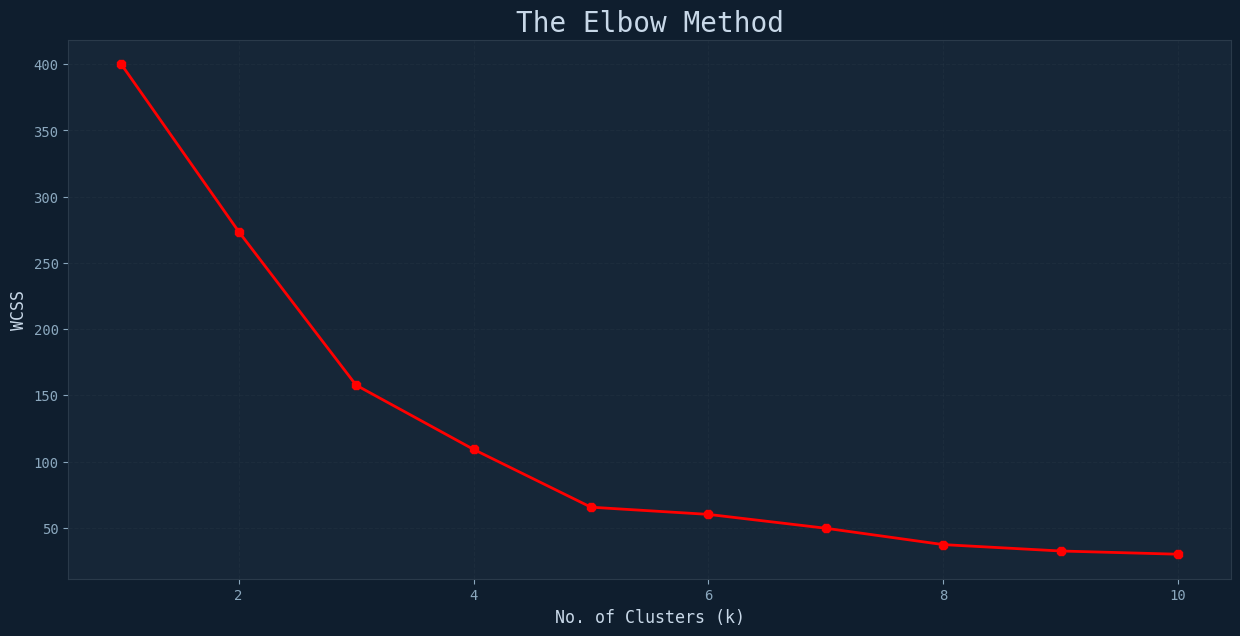

------------------------------
Clusters (k)    | Silhouette Score
------------------------------
2               | 0.3973
3               | 0.4666
4               | 0.4943
5               | 0.5547
6               | 0.5138
7               | 0.5020
8               | 0.4550
9               | 0.4567
10              | 0.4448
------------------------------
Optimal K suggested by Silhouette Score: 5 (Score: 0.5547)


In [ ]:
wcss = []
silhouette_scores = {}

# We run from 1 to 10 for WCSS, but silhouette needs at least 2 clusters
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

    # Calculate silhouette score for k > 1
    if i > 1:
        score = silhouette_score(X_scaled, km.labels_)
        silhouette_scores[i] = score

# Plotting the Elbow Method
plt.figure(figsize=(15, 7))
plt.plot(range(1, 11), wcss, linewidth=2, color="red", marker="8")
plt.ylabel('WCSS')
plt.xlabel('No. of Clusters (k)')
plt.title('The Elbow Method', fontsize=20)
plt.grid(True, alpha=0.3)
plt.show()

# Output the Silhouette Scores below the graph
print("-" * 30)
print(f"{'Clusters (k)':<15} | {'Silhouette Score':<15}")
print("-" * 30)
for k, score in silhouette_scores.items():
    print(f"{k:<15} | {score:.4f}")
print("-" * 30)

# Logic to suggest the best K based on Silhouette
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Optimal K suggested by Silhouette Score: {best_k} (Score: {silhouette_scores[best_k]:.4f})")

In [ ]:
# Based on the elbow plot, k=5 is the optimal number of clusters
# Train the model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


---
## Silhouette Score — Validating the Clusters

The Silhouette Score provides a **quantitative measure** of clustering quality:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

Where:
- $a(i)$ = mean distance from point $i$ to **all other points in its cluster** (cohesion)
- $b(i)$ = mean distance from point $i$ to **all points in the nearest OTHER cluster** (separation)

| Score | Interpretation |
|-------|----------------|
| +1.0  | Perfect — dense, well-separated clusters |
| 0.0   | On the boundary between two clusters |
| −1.0  | Misclassified — should be in the other cluster |


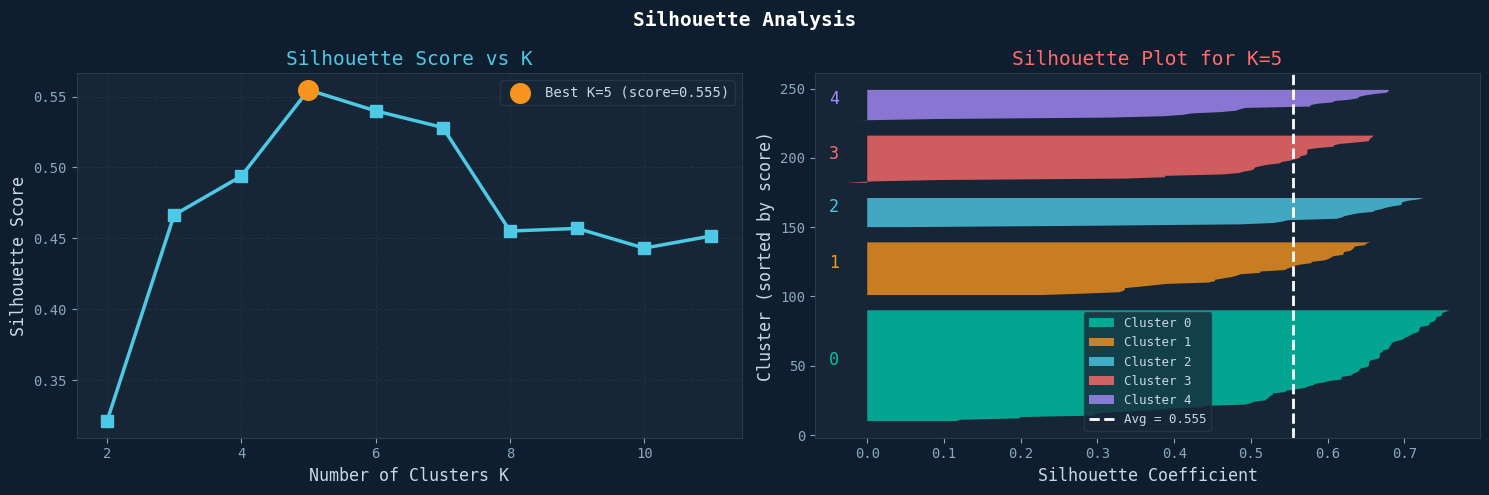

✅  Silhouette Score for K=5: 0.5547
    Wide, uniform bars = well-defined clusters.
    Thin bars below average line = points near a boundary.


In [ ]:
# Silhouette Score vs K
sil_scores = []

for k in range(2, 12):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl)
    sil_scores.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Silhouette Analysis", fontsize=14, fontweight='bold', color='white')

# Left: Score vs K
k_vals = list(range(2, 12))
axes[0].plot(k_vals, sil_scores, marker='s', color=PALETTE[2], linewidth=2.5, markersize=9)
axes[0].scatter([5], [sil_scores[3]], s=200, c=PALETTE[1], zorder=5,
                label=f'Best K=5 (score={sil_scores[3]:.3f})')
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs K", color=PALETTE[2])
axes[0].legend()
axes[0].grid(True)

# Right: Silhouette plot for K=5
km5 = KMeans(n_clusters=5, n_init=10, random_state=42)
lbl5 = km5.fit_predict(X_scaled)
sample_sil = silhouette_samples(X_scaled, lbl5)

y_lower = 10
for k in range(5):
    sil_k = np.sort(sample_sil[lbl5 == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                          facecolor=PALETTE[k], alpha=0.8, label=f'Cluster {k}')
    axes[1].text(-0.05, y_lower + 0.5 * size_k, str(k), color=PALETTE[k], fontsize=12)
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, lbl5)
axes[1].axvline(x=avg_score, color='white', linestyle='--', lw=2,
                label=f'Avg = {avg_score:.3f}')
axes[1].set_xlabel("Silhouette Coefficient")
axes[1].set_ylabel("Cluster (sorted by score)")
axes[1].set_title("Silhouette Plot for K=5", color=PALETTE[3])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅  Silhouette Score for K=5: {avg_score:.4f}")
print("    Wide, uniform bars = well-defined clusters.")
print("    Thin bars below average line = points near a boundary.")

**Clustering**

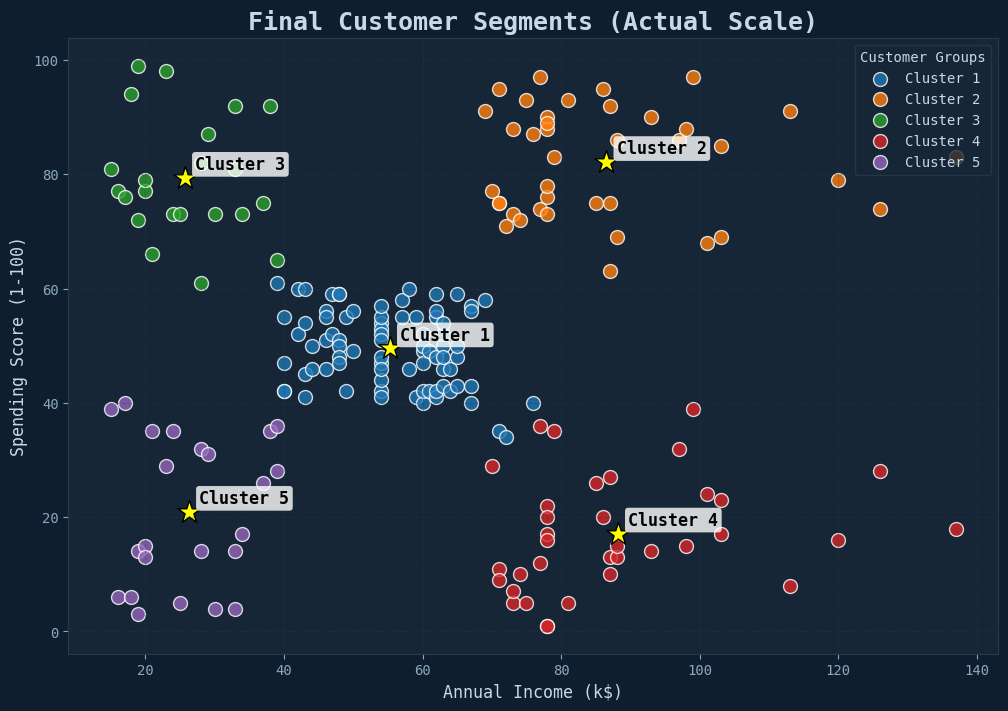

In [ ]:
# Update the dataframe labels to start from 1
df['Cluster'] = y_kmeans + 1

plt.figure(figsize=(12, 8))

# Plot using original (unscaled) values from the dataframe
# We loop from 1 to 5 inclusive
for i in range(1, 6):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=100, label=f'Cluster {i}', edgecolors='white', alpha=0.8)

#Calculate and Plot the Centroids in original scale
# Instead of using the scaled centers, we find the mean of the actual data
for i in range(1, 6):
    actual_center_x = df[df['Cluster'] == i]['Annual Income (k$)'].mean()
    actual_center_y = df[df['Cluster'] == i]['Spending Score (1-100)'].mean()

    # Plot the Centroid star
    plt.scatter(actual_center_x, actual_center_y, s=300, c='yellow',
                marker='*', edgecolors='black')

    # Add the Label directly next to the centroid
    plt.text(actual_center_x + 1.5, actual_center_y + 1.5, f'Cluster {i}',
             fontsize=12, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# Final Plot Formatting
plt.title('Final Customer Segments (Actual Scale)', fontsize=18, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title="Customer Groups", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()



---

### Understanding the Results
After running this code, you will see a clear separation of your customers. Here is how the marketing team usually interprets those **5 groups**:

1.  **Cluster 1 (Middle Class):** High stability, average income, and average spending.
2.  **Cluster 2 (Target/Stars):** High income and high spending. **(Priority #1)**.
3.  **Cluster 3 (Careless):** Low income but high spending. These are likely younger, impulsive shoppers.
4.  **Cluster 4 (Stingy):** High income but low spending. They have the money but don't like your current offers.
5.  **Cluster 5 (Careful):** Low income and low spending.



### Why `init='k-means++'`?
By default, K-Means picks starting points randomly. Sometimes, it picks two points that are very close together, which leads to poor clustering. `k-means++` is a smarter initialization trick that spreads out the initial centroids, making the algorithm much more likely to find the **globally optimal** clusters on the first try.



---



---



# **Practical 2**

# **Hierarchical Clustering**

Hierarchical clustering is a method of cluster analysis that seeks to build a hierarchy of clusters. Unlike K-Means, it doesn't require you to pre-define the number of clusters; instead, it provides a visual map of how data points relate to each other at every level of similarity.

---

## The Two Main Strategies

### Agglomerative (Bottom-Up)
This is the most popular approach. Think of it like building a family tree from the kids up to the ancestors.
1.  **Individual Start:** Every data point starts as its own unique cluster.
2.  **Merging:** The algorithm identifies the two clusters that are most similar and merges them.
3.  **Completion:** This repeats until every point is part of one single, massive cluster.

### Divisive (Top-Down)
This is the opposite approach—starting with one giant group and breaking it down.
1.  **Single Start:** All data points begin in one "root" cluster.
2.  **Splitting:** The algorithm recursively splits the most diverse cluster into two.
3.  **Completion:** This continues until every point is in its own individual cluster.

---

## Visualizing with the Dendrogram

The defining feature of this algorithm is the **Dendrogram**, a tree-like diagram that records every merge or split.



* **Height Matters:** The vertical axis represents the distance or "dissimilarity" between clusters. A tall vertical bridge between two groups means they are very different.
* **Choosing Clusters:** To decide how many clusters you want, you draw a horizontal line across the dendrogram. The number of vertical lines your horizontal line crosses determines the number of clusters.

---

## Measuring Distance (Linkage)

Since the algorithm needs to know which clusters are "closest," you have to choose a linkage method:

* **Single Linkage:** Looks at the distance between the two **closest** points in different clusters. This can lead to "chaining," where clusters become long and thin.
* **Complete Linkage:** Looks at the distance between the two **farthest** points. This usually produces more compact, spherical clusters.
* **Average Linkage:** Calculates the average distance between all points in two clusters.
* **Ward’s Method:** Focuses on minimizing the variance (the "spread") within clusters. It is often the go-to choice for creating clean, even groups.

---

## Why Use It?

* **Discovery:** It’s great when you don’t know how many groups naturally exist in your data.
* **Interpretability:** The dendrogram provides a clear, logical map of data relationships.
* **Versatility:** You can use any distance metric (like Euclidean or Manhattan) depending on your data type.

However, keep in mind that it is computationally heavy. While K-Means is fast, hierarchical clustering can become very slow as your dataset grows because it has to calculate the distance between every single pair of points.

**Why Dendogram**

The dendrogram is the "DNA" of hierarchical clustering. We use it for three main reasons:

* **Discovery over Guesswork:** Unlike K-Means, where you must guess $K$ first, the dendrogram shows you the **entire structure** first. You decide where to cut *after* seeing how the data relates.
* **Visual Justification:** The **Longest Vertical Distance** gives you a clear, mathematical reason for your cluster count. If there is a big vertical gap, the clusters are naturally stable.
* **Nested Relationships:** it shows "clusters within clusters." You can see that "High Earners" might be one big group that later splits into "Spenders" and "Savers."
* **Outlier Detection:** Points that merge very late (at the top) are easily identified as outliers.

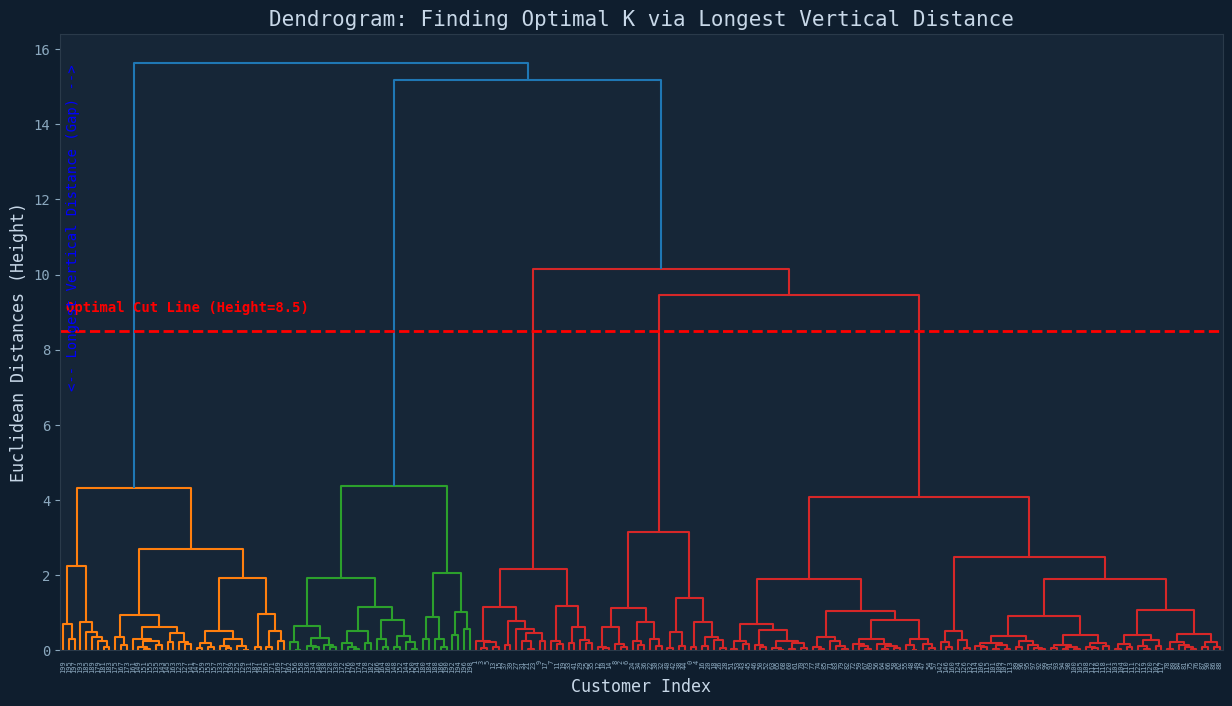

By cutting at height 8.5, we find 5 clusters.


In [ ]:
# Dendrogram Visualisation
#Create the Linkage Matrix (using Ward's method)
Z = sch.linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(Z)

# Drawing the "Optimal Cut"
# Looking at the Y-axis, there is a large gap between height 7 and 11.
# We choose 8.5 to cut through that gap.
cut_height = 8.5
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)

# Adding Annotations to explain the "Gap Rule"
plt.title('Dendrogram: Finding Optimal K via Longest Vertical Distance', fontsize=15)
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distances (Height)')

# Labeling the "Gap"
plt.text(x=10, y=cut_height + 0.5, s=f'Optimal Cut Line (Height={cut_height})', color='red', fontweight='bold')
plt.text(x=10, y=cut_height - 1.5, s='<-- Longest Vertical Distance (Gap) -->', color='blue', rotation=90)

plt.show()

#Logic to count clusters based on that line
k_clusters = len(np.unique(fcluster(Z, t=cut_height, criterion='distance')))
print(f"By cutting at height {cut_height}, we find {k_clusters} clusters.")

**Silhouette Analysis for Hierarchical Clustering**

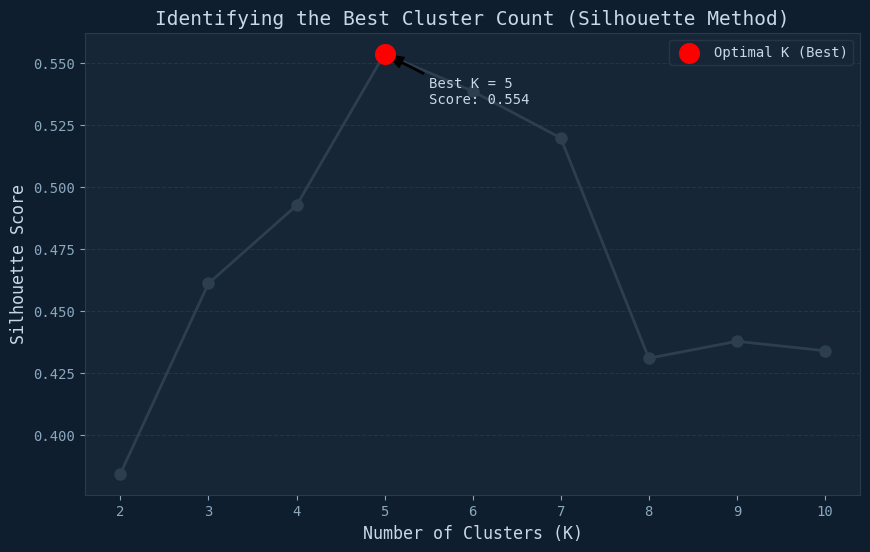

In [ ]:
#Calculate scores
k_range = range(2, 11)
scores = []
for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

#Find the best K
best_index = np.argmax(scores)
best_k = k_range[best_index]
best_score = scores[best_index]

# Plot with "Point on the Best"
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', color='#2c3e50', linewidth=2, markersize=8)

# Highlight the best point
plt.scatter(best_k, best_score, color='red', s=200, zorder=5, label='Optimal K (Best)')
plt.annotate(f'Best K = {best_k}\nScore: {best_score:.3f}',
             xy=(best_k, best_score),
             xytext=(best_k + 0.5, best_score - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.title('Identifying the Best Cluster Count (Silhouette Method)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
#training model with agglomerative clustering
# Initialize and fit the Agglomerative Model
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Add the cluster labels back to the original dataframe
df['Cluster'] = y_hc + 1 # Shifting by 1 so clusters are 1-5

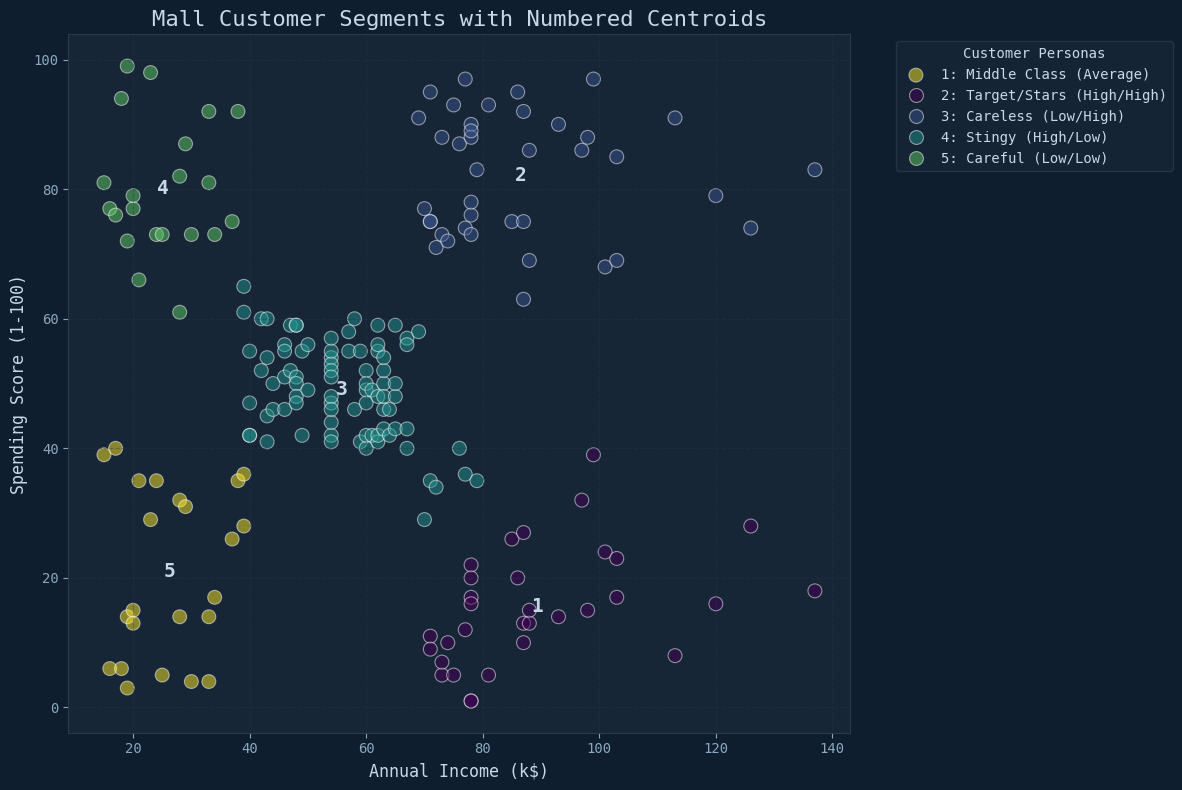

In [ ]:
#Visualizing the Segments

centroids = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.5
)


for i in centroids.index:
    x_coord = centroids.loc[i, 'Annual Income (k$)']
    y_coord = centroids.loc[i, 'Spending Score (1-100)']


    # Place the cluster number (1-5) inside the circle
    plt.text(
        x_coord, y_coord, str(i),
        fontsize=14, fontweight='bold',
        va='center', ha='center', zorder=11
    )

plt.title('Mall Customer Segments with Numbered Centroids', fontsize=16)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# Define the legend based on your specific definitions
legend_labels = [
    '1: Middle Class (Average)',
    '2: Target/Stars (High/High)',
    '3: Careless (Low/High)',
    '4: Stingy (High/Low)',
    '5: Careful (Low/Low)'
]
plt.legend(title='Customer Personas', labels=legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()